In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from tqdm import tqdm

import importlib

import global_mapping as gm
import w1_tree as wt
import representation_metrics as rm 
import scipy.spatial.distance as spd

import plotly.express as px
import plotly.graph_objects as go

import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.patches as patches
import seaborn as sns


PATH = "../data_clean/"


In [2]:
df_country = pd.read_csv("../data/Floriana_country_info.csv")

df_cs = pd.read_csv(PATH+"df_country_subfield_roll_5y.csv", index_col=[0, 1, 2]).dropna(how="all")
df_cs.columns = df_cs.columns.astype(int)

year_list = df_cs.index.get_level_values(1).unique().sort_values().to_list()
country_list = df_cs.index.get_level_values(0).unique().sort_values().to_list()

df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

df_total = (
    df_cs
    .sum(axis=1)
    .to_frame("total")
    .reset_index()
    .pivot(index=["country", "year"], columns=["mode"])
    .xs("total", axis=1)
    .assign(collab_share = lambda df: df.collaborative / (df.collaborative + df.individual))
)

df_dist = pd.read_csv(PATH+"df_dist_country.csv", index_col=[0, 1, 2])

In [3]:
df_subfield = (
    pd.read_csv(PATH+"df_topics.csv")
    [["subfield_id", "subfield_name", "field_id", "field_name", "domain_id", "domain_name"]]
    .drop_duplicates()
    .sort_values(["domain_id", "field_id", "subfield_id"])
)

w1_tree = wt.W1Tree(df_subfield[["domain_id", "field_id", "subfield_id"]], weight_base=1.0)

[0.16666667 0.16666667 0.16666667 0.16666667]


In [4]:
sf_list = df_subfield.subfield_id.to_list()

In [5]:
df_mapping_indiv = pd.read_csv(PATH+"df_mapping_indiv.csv")
df_mapping_collab = pd.read_csv(PATH+"df_mapping_collab.csv")

In [6]:
df_global_indiv = (
    df_prob.xs("individual", level=2)
    .merge(df_mapping_indiv[["country", "year", "dynamic_cluster"]], left_index=True, right_on=["country", "year"], how="right")
    .set_index(["country", "year", "dynamic_cluster"])
    .groupby(level=1)
    .mean()
)
df_global_indiv = df_global_indiv.div(df_global_indiv.sum(axis=1), axis=0)

df_global_collab = (
    df_prob.xs("collaborative", level=2)
    .merge(df_mapping_collab[["country", "year", "dynamic_cluster"]], left_index=True, right_on=["country", "year"], how="right")
    .set_index(["country", "year", "dynamic_cluster"])
    .groupby(level=1)
    .mean()
)
df_global_collab = df_global_collab.div(df_global_collab.sum(axis=1), axis=0)

In [7]:
domain_list = df_subfield.domain_id.drop_duplicates().to_list()

In [12]:
df_subfield

,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name
1597,1100,General Agricultural and Biological Sciences,11,Agricultural and Biological Sciences,1,Life Sciences
341,1102,Agronomy and Crop Science,11,Agricultural and Biological Sciences,1,Life Sciences
156,1103,Animal Science and Zoology,11,Agricultural and Biological Sciences,1,Life Sciences
269,1104,Aquatic Science,11,Agricultural and Biological Sciences,1,Life Sciences
7,1105,"Ecology, Evolution, Behavior and Systematics",11,Agricultural and Biological Sciences,1,Life Sciences
...,...,...,...,...,...,...
2398,3609,Occupational Therapy,36,Health Professions,4,Health Sciences
1434,3611,Pharmacy,36,Health Professions,4,Health Sciences
525,3612,"Physical Therapy, Sports Therapy and Rehabilit...",36,Health Professions,4,Health Sciences
865,3614,Radiological and Ultrasound Technology,36,Health Professions,4,Health Sciences


In [27]:
mapping = df_subfield[["subfield_id", "field_name"]].set_index("subfield_id").to_dict()["field_name"]

In [31]:
df_cs_sf = (
    df_cs
    .groupby(mapping, axis=1)
    .sum()
)

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_4589/2293794221.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_cs


In [137]:
domain_name = "Physical Sciences"

field_list = (
    df_subfield
    [["field_name", "domain_name"]]
    .drop_duplicates()
    .query("domain_name == @domain_name")
).field_name.to_list()

In [138]:
field_list

['Chemical Engineering',
 'Chemistry',
 'Computer Science',
 'Earth and Planetary Sciences',
 'Energy',
 'Engineering',
 'Environmental Science',
 'Materials Science',
 'Mathematics',
 'Physics and Astronomy']

In [139]:
dfshareyy = (
    df_cs_sf.xs("individual", level=2)
    .div(df_cs_sf.xs("individual", level=2)+df_cs_sf.xs("collaborative", level=2))
    [field_list]
    .dropna(how="all")
    .reset_index()
    .melt(id_vars=["country", "year"], var_name="field", value_name="domestic_share")
    .query("year in [1983, 2003, 2023]")
    .dropna(subset=["domestic_share"])
)

In [140]:
domain_colors={'Life Sciences':'#81b29a', 'Physical Sciences':'#3d405b', 'Social Sciences':'#e07a5f', 'Health Sciences':'#f4f1de'}

In [141]:
def white_to_color(color, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"white_to_{color}",
        [(0.0, "white"), (0.2, "white"), (1, color)],
        N=n
    )

In [ ]:
cmap = white_to_color(domain_colors[domain_name])
field_colors = dict(zip(field_list, [mcolors.to_hex(c, keep_alpha=True) for c in cmap(np.linspace(0.2, 1, len(field_list)+1))][1:]))

In [144]:
field_colors

{'Chemical Engineering': '#ececefff',
 'Chemistry': '#d8d9deff',
 'Computer Science': '#c5c6ceff',
 'Earth and Planetary Sciences': '#b1b2bdff',
 'Energy': '#9ea0adff',
 'Engineering': '#8a8c9cff',
 'Environmental Science': '#77798cff',
 'Materials Science': '#63657bff',
 'Mathematics': '#50536bff',
 'Physics and Astronomy': '#3d405bff'}

In [145]:
# df_subfield.query("field_name == 'Life Sciences'")

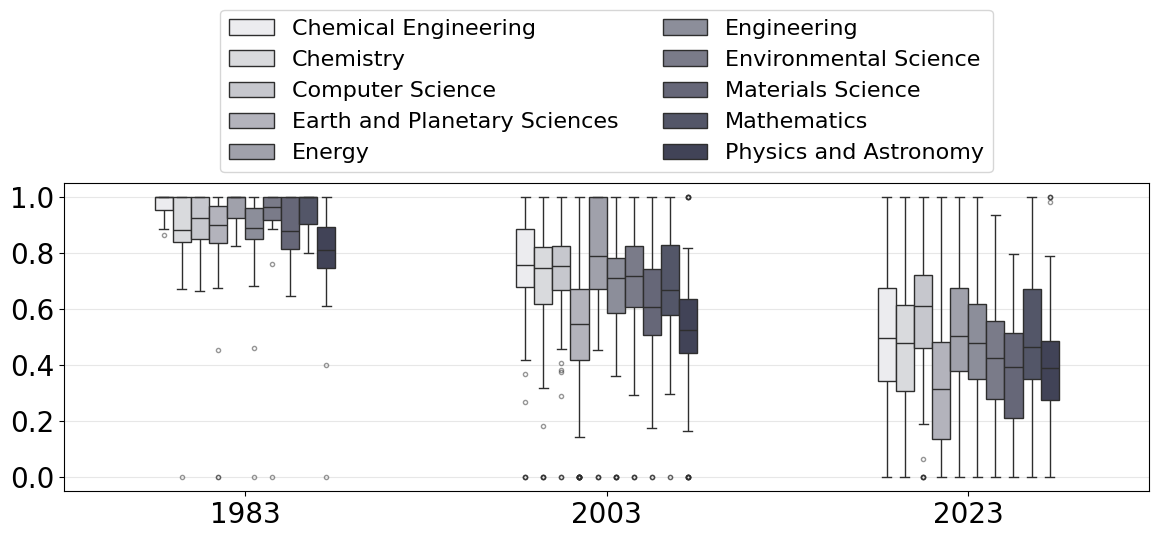

In [146]:
# dfshareyy=dfshare[dfshare['year'].isin([1983, 2003, 2023])].copy()
plt.figure(figsize=(14, 4))
sns.boxplot(data=dfshareyy, x='year', y='domestic_share', hue='field', width=0.5, showfliers=True,palette=field_colors,flierprops={"marker": "o", "markersize": 3, "alpha": 0.5})
plt.xticks(size=20)
plt.yticks(size=20)
plt.xlabel(None)
plt.ylabel(None, size=0)
plt.legend(fontsize=16, loc="lower center", bbox_to_anchor=(0.5, 1), ncols=2)
plt.grid(axis="y", alpha=0.3)
plt.savefig(f"../{domain_name}_fields_v1.jpg", dpi=1000, bbox_inches='tight')

In [51]:
df_subfield[["domain_id", "domain_name"]].drop_duplicates()

,domain_id,domain_name
1597,1,Life Sciences
3498,2,Social Sciences
289,3,Physical Sciences
1922,4,Health Sciences


In [52]:
domain_name = "Health Sciences"
sf_domain = df_subfield.query("domain_name == @domain_name").subfield_id.to_list()

In [53]:
df_global_indiv.loc[2023].loc[sf_domain].sort_values(ascending=False).to_frame("prob").reset_index(names=["subfield_id"]).merge(df_subfield[["subfield_id", "subfield_name"]], on="subfield_id")

,subfield_id,prob,subfield_name
0,2746,0.018305,Surgery
1,3600,0.017116,General Health Professions
2,2739,0.016763,"Public Health, Environmental and Occupational ..."
3,2713,0.013110,Epidemiology
4,2740,0.010937,Pulmonary and Respiratory Medicine
...,...,...,...
58,3402,0.000226,Equine
59,2922,0.000194,Research and Theory
60,2910,0.000192,"Issues, ethics and legal aspects"
61,2726,0.000122,Microbiology


In [54]:
(
    df_global_indiv
    .loc[2023]
    .to_frame("prob")
    .reset_index(names=["subfield_id"])
    .merge(df_subfield[["subfield_id", "subfield_name", "domain_name"]], on="subfield_id")
    .groupby("domain_name")
    .prob
    .sum()
)

domain_name
Health Sciences      0.216902
Life Sciences        0.120972
Physical Sciences    0.320777
Social Sciences      0.341349
Name: prob, dtype: float64

In [55]:
(
    df_global_collab
    .loc[2023]
    .to_frame("prob")
    .reset_index(names=["subfield_id"])
    .merge(df_subfield[["subfield_id", "subfield_name", "domain_name"]], on="subfield_id")
    .groupby("domain_name")
    .prob
    .sum()
)

domain_name
Health Sciences      0.236067
Life Sciences        0.163645
Physical Sciences    0.426887
Social Sciences      0.173401
Name: prob, dtype: float64

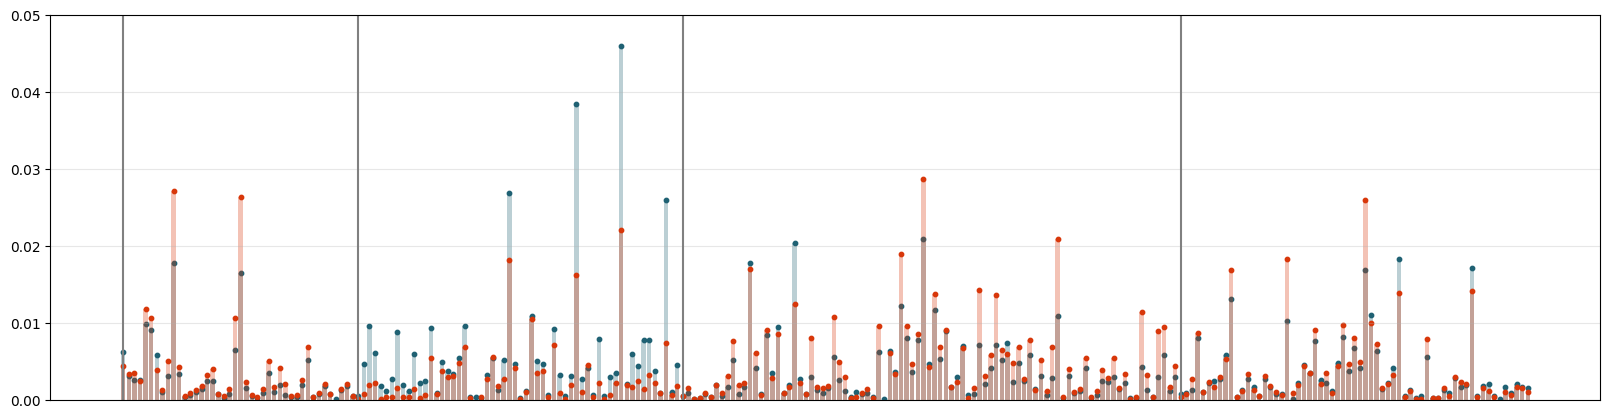

In [56]:
fig, ax = plt.subplots(figsize = (20, 5))
ax.bar(df_global_indiv[sf_list].loc[2023].index.astype(str), df_global_indiv[sf_list].loc[2023].values, color="#1F6173", alpha=0.3)
ax.scatter(df_global_indiv[sf_list].loc[2023].index.astype(str), df_global_indiv[sf_list].loc[2023].values, s=10, color="#1F6173")

ax.bar(df_global_collab[sf_list].loc[2023].index.astype(str), df_global_collab[sf_list].loc[2023].values, color="#D8370A", alpha=0.3)
ax.scatter(df_global_collab[sf_list].loc[2023].index.astype(str), df_global_collab[sf_list].loc[2023].values, s=10, color="#D8370A")

for domain in domain_list:
    start_domain = df_subfield.query("domain_id == @domain").subfield_id.iloc[0].astype(str)
    ax.axvline(start_domain, color="grey")

# ax.axvline("1110", color="red")

ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 0.05)
_ = ax.set_xticks([],labels=[])

# fig.savefig(
#     "profiles.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight"
# )